## Exploratory Data Analysis (EDA)

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Dataset & Dataset Overview

In [305]:
INPUT_FILE = "CEAS_08.csv"
df = pd.read_csv("C:\\Users\\PIXEL-PC\\Desktop\\SIC capstone\\CEAS_08.csv")
print("shape:", df.shape)
print("columns:", df.columns)
df.head()

shape: (39154, 7)
columns: Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='object')


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


## 2. Missing Values & Duplicate Records

In [307]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count")

,missing_count,missing_pct
subject,28,0.071512
receiver,462,1.179956


In [308]:
print("Fully duplicate rows:", df.duplicated().sum())

if "body" in df.columns:
    print("Duplicate email bodies:", df.duplicated(subset=["body"]).sum())

Fully duplicate rows: 0
Duplicate email bodies: 0


## 3. Class Distribution

label
1    21842
0    17312
Name: count, dtype: int64
label
1    55.78485
0    44.21515
Name: proportion, dtype: float64


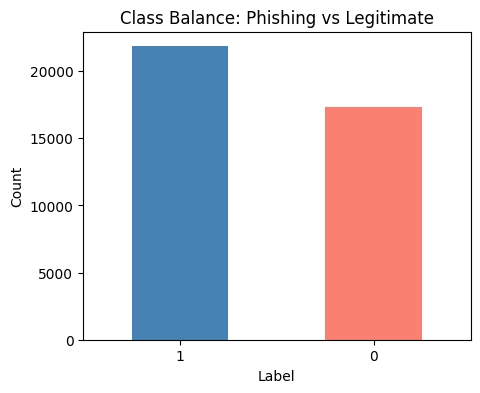

In [309]:
label_col = "label"

counts = df[label_col].value_counts()
percentages = df[label_col].value_counts(normalize=True) * 100

print(counts)
print(percentages)

plt.figure(figsize=(5, 4))
counts.plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Class Balance: Phishing vs Legitimate")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


## 4. Email Body Analysis

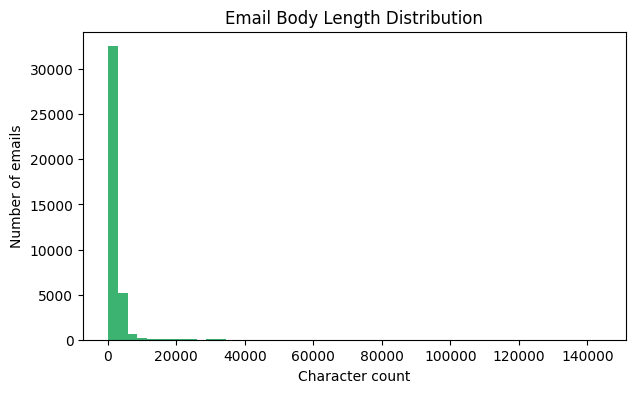

count     39154.000000
mean       1571.079813
std        3615.810576
min          14.000000
25%         224.000000
50%         570.000000
75%        1643.000000
max      143996.000000
Name: body, dtype: float64

In [310]:
body_length = df["body"].astype(str).apply(len)

plt.figure(figsize=(7, 4))
plt.hist(body_length, bins=50, color="mediumseagreen")
plt.title("Email Body Length Distribution")
plt.xlabel("Character count")
plt.ylabel("Number of emails")
plt.show()

body_length.describe()

In [311]:
body_length = df["body"].astype(str).apply(len)

df.loc[
    body_length.nlargest(3).index,
    ["subject", "body", "label", "urls"]
]

,subject,body,label,urls
3634,Buzz Alert! Ten things the cool kids are talki...,"WhatIs.com February 12, 2008 Published by Wha...",0,1
5290,"ietf-dkim Digest, Vol 107, Issue 7",Send ietf-dkim mailing list submissions to \tg...,0,1
4363,[R] P values in non linear regression and sing...,"Dear all, We are trying to fit a non linear mo...",0,1


In [312]:
body_length = df["body"].astype(str).apply(len)

df.assign(temp_body_length=body_length).groupby("label")["temp_body_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17312.0,2542.186287,5080.634677,14.0,709.00,1252.0,2468.0,143996.0
1,21842.0,801.379452,1279.876356,16.0,160.25,278.0,566.0,10782.0


## 5. URL Indicator Analysis

In [313]:
if "urls" in df.columns:
    print(df["urls"].value_counts())
    print(df["urls"].value_counts(normalize=True) * 100)
else:
    print("No 'urls' column found — check actual column names with df.columns")

urls
1    26232
0    12922
Name: count, dtype: int64
urls
1    66.996986
0    33.003014
Name: proportion, dtype: float64


## 6. Subject Analysis

In [314]:
subject_length = df["subject"].fillna("").astype(str).apply(len)

print(subject_length.describe())

print(
    pd.DataFrame({
        "label": df["label"],
        "subject_length": subject_length
    }).groupby("label")["subject_length"].describe()
)

count    39154.000000
mean        38.896537
std         20.769595
min          0.000000
25%         25.000000
50%         35.000000
75%         50.000000
max        285.000000
Name: subject, dtype: float64
         count       mean        std  min   25%   50%   75%    max
label                                                             
0      17312.0  48.084277  21.247088  0.0  33.0  45.0  61.0  268.0
1      21842.0  31.614321  17.191599  0.0  20.0  27.0  40.0  285.0


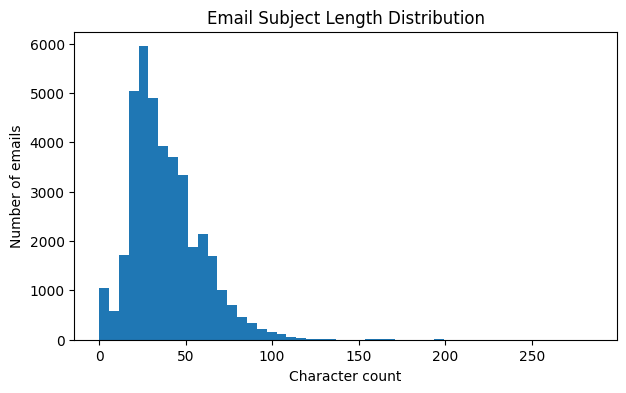

In [315]:
subject_length = df["subject"].fillna("").astype(str).apply(len)

plt.figure(figsize=(7,4))

plt.hist(subject_length, bins=50)

plt.title("Email Subject Length Distribution")
plt.xlabel("Character count")
plt.ylabel("Number of emails")

plt.show()

## 7. Sender and Receiver Analysis

In [316]:
print("Unique senders:", df["sender"].nunique())
print("Unique receivers:", df["receiver"].nunique())



Unique senders: 24578
Unique receivers: 3693


In [317]:
print(df["sender"].value_counts().head(10))

sender
qydlqcws-iacfym@issues.apache.org                 462
Guido van Rossum <hoauf@python.org>               295
"\\"Martin v. Löwis\\"" <qpnysl@v.loewis.de>      276
"Carlos E. R." <vyjwd.trpcau@telefonica.net>      208
Aaron Kulkis <cmiqlkx91@hotpop.com>               183
Rafael Garcia-Suarez <pvhuhqgncrxnu@gmail.com>    158
Christian Heimes <wluhe@cheimes.de>               152
Barry Warsaw <pjaxq@python.org>                   131
iybz@pobox.com                                    124
Per Jessen <uee@computer.org>                     113
Name: count, dtype: int64


## 8. Date Quality Check

In [318]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)

print("Date range:")
print(df["date"].min())
print(df["date"].max())

print("Missing dates:", df["date"].isnull().sum())

Date range:
1980-01-04 05:39:00+00:00
2100-05-27 19:54:05+00:00
Missing dates: 15


In [319]:
print(df["date"].sort_values().head(10))
print(df["date"].sort_values(ascending=False).head(10))

33125   1980-01-04 05:39:00+00:00
15273   1981-10-07 11:41:34+00:00
7199    1986-01-01 11:08:10+00:00
4068    1986-08-06 04:16:02+00:00
12102   1998-03-02 14:32:36+00:00
37806   1998-03-04 12:54:20+00:00
38231   1999-01-05 02:45:17+00:00
25305   2000-01-01 01:22:06+00:00
32675   2000-01-01 13:38:03+00:00
22485   2000-01-01 23:19:46+00:00
Name: date, dtype: datetime64[ns, UTC]
29606   2100-05-27 19:54:05+00:00
18872   2100-05-27 01:54:02+00:00
10755   2100-05-26 11:37:05+00:00
7009    2100-05-26 03:43:02+00:00
107     2086-08-06 00:34:28+00:00
8810    2080-08-06 12:19:34+00:00
9506    2031-07-14 02:46:35+00:00
20322   2020-06-19 22:30:58+00:00
20321   2020-06-19 22:30:58+00:00
980     2012-08-05 19:24:46+00:00
Name: date, dtype: datetime64[ns, UTC]


In [320]:
print(df.loc[
    (df["date"] < "1990-01-01") | (df["date"] > "2026-12-31"),
    ["sender", "receiver", "subject", "date", "label"]
].sort_values("date").to_string(index=False))

                                             sender                                                                                                                                                                                                  receiver                                       subject                      date  label
     Fern Trotter <AidacountHoyt@lashawnbarber.com> 7eac07b0ac7489227e7e5bcf767b2dd3dd@gvc.ceas-challenge.cc, user8.1@gvc.ceas-challenge.cc, 7eac07b0ac7489227e7e5bcf767b2dd37@gvc.ceas-challenge.cc, 7eac07b0ac7489227e7e5bcf767b2dd3d@gvc.ceas-challenge.cc     Italian-crafted Rolex - only $65 - $140!! 1980-01-04 05:39:00+00:00      1
         Kate Capps <JosefinaplatenMelvin@tmaa.com>                                                                                                                                                                          vlfiscella@gvc.ceas-challenge.cc                Replica Rolex Swiss Watches    1981-10-07 11:41:34+00:00      1
 

In [321]:
print(df[df["date"].isna()][["sender", "receiver", "subject", "date"]])

                                 sender                            receiver  \
6279          msvksyhq@bodyandcolor.com      cstheory@gvc.ceas-challenge.cc   
7410             mpghaoeq@blumhorst.com      cstheory@gvc.ceas-challenge.cc   
8611          rjjtryw@boxerproperty.com      cstheory@gvc.ceas-challenge.cc   
9600              qoaikmk@boltongrp.com      cstheory@gvc.ceas-challenge.cc   
12253          kywyeayhcmu@bosaship.com      cstheory@gvc.ceas-challenge.cc   
13848             ktoijxikguob@bol3.com      cstheory@gvc.ceas-challenge.cc   
16105           cyll@bradenbenefits.com      cstheory@gvc.ceas-challenge.cc   
17580                     tegocn@qq.com      cstheory@gvc.ceas-challenge.cc   
18509             tengqi@mail.china.com      cstheory@gvc.ceas-challenge.cc   
19436              tegenius@icqmail.com       user2.1@gvc.ceas-challenge.cc   
20209          gtfa@blueunderground.com  user8.2-ext1@gvc.ceas-challenge.cc   
22195  terrinn@aquabluepoolsandspas.com      cstheor

In [322]:
before_2000 = df["date"] < "2000-01-01"
after_2020 = df["date"] > "2020-12-31"

print("Unusual dates by label:")
print(df[before_2000 | after_2020]["label"].value_counts())

print("\nPercentage of each class with unusual dates:")
print(
    df.assign(unusual_date=before_2000 | after_2020)
      .groupby("label")["unusual_date"]
      .mean() * 100
)

Unusual dates by label:
label
1    14
Name: count, dtype: int64

Percentage of each class with unusual dates:
label
0    0.000000
1    0.064097
Name: unusual_date, dtype: float64


## 9. Common Words

In [323]:
from collections import Counter
import re

def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    return re.findall(r'\b[a-z]{3,}\b', text)

all_words = []
for text in df["body"].dropna().sample(min(2000, len(df)), random_state=42):
    all_words.extend(simple_tokenize(text))

common = Counter(all_words).most_common(20)
pd.DataFrame(common, columns=["word", "count"])

,word,count
0,the,13335
1,com,7110
2,http,6755
3,and,6465
4,cnn,6006
5,submission,4848
6,www,4757
7,html,4171
8,for,3596
9,video,3315


## 10. Data Consistency Check

In [324]:
conflicting_bodies = (
    df.groupby("body")["label"]
      .nunique()
)

print("Bodies with conflicting labels:", (conflicting_bodies > 1).sum())

Bodies with conflicting labels: 0


## Summary 
- Dataset shape: 39,154 rows × 7 columns

- Columns with missing data: receiver (1.18%), subject (0.07%) — both minor. Missing-value handling will be decided during preprocessing.

- Duplicate rows found: 0 (both full-row and body-only duplicates)

- Class balance (phishing % vs legitimate %): 55.8% phishing (1) vs 44.2% legitimate (0) — reasonably balanced, with no severe class imbalance observed

- Body length range / outliers noticed: Highly skewed. Minimum 14 characters, median 570, mean 1,571, and maximum approximately 144,000 characters. A few extremely long emails were observed and should be considered during later preprocessing.

- % of emails containing a URL: 67% (urls=1), 33% (urls=0)

- The email body contains both normal text and technical content such as URLs and HTML tags. Words such as http, www, com, org, and html appear frequently because URLs and HTML are included in the body. This observation will be considered during the NLP preprocessing stage.

- Conflicting labels: No identical email bodies were found with different labels.

- Date column: The original date column contains no null values, but 15 date values could not be parsed successfully when converted to datetime. The parsed dates range from 1980 to 2100, with 14 unusual dates occurring in phishing emails and none in legitimate emails. These unusual values represent only 0.064% of phishing emails, so the date column should be reviewed before being used as an ML feature.


This summary + the plots above are what preprocessing decisions in `data_preprocessing.ipynb` should be based on.